# Задание 1. Работа с массивами, статистика и обработка данных

## 1. Генерация данных

In [2]:
#сгенерируйте numpy-массив размером 100 с равномерным распределением от -100 до 50 (numpy.random.uniform);
import numpy as np


array_uniform = np.random.uniform(-100, 50, 100)
print(array_uniform[:15])

[-27.55738187  34.86986616  11.76015102  30.21310397 -22.04887151
  12.77125284 -83.33227488   5.06516663  -9.82919535  -4.94623083
 -89.92962116  15.05856511 -62.35487129 -69.3196482  -97.17877998]


In [3]:
# сгенерируйте массив из 100 случайных значений по
# нормальному распределению со средним 10 и σ = 5
# (numpy.random.normal);
array_normal = np.random.normal(10, 5, 100)
print(array_normal[:15])

[ 9.0508701  17.8584198  10.78386582  4.03311739 10.14033015  2.00823048
  6.4207899   3.81597428 11.00925262 16.30916311 15.46056546  7.07334961
  9.84325413  6.89378415  9.53102739]


In [4]:
# сгенерируйте массив из 100 значений, распределённых по
# экспоненциальному закону с параметром 𝜆 = 0.5
# (numpy.random.exponential).
scale = 1/0.5
array_exponential = np.random.exponential(scale, 100)
print(array_exponential[:15])

[0.58074009 3.44897946 1.02566663 2.86177899 3.97576985 1.74576371
 3.59137207 1.46475112 1.45281141 4.1198287  0.87002578 6.17363238
 1.17588976 1.48419209 1.98419795]


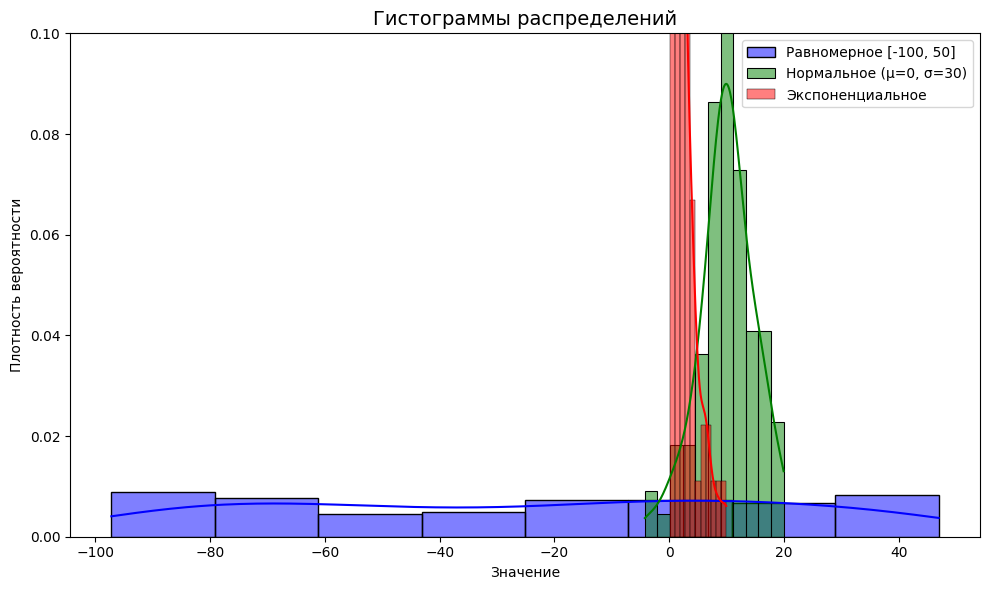

In [5]:
# постройте гистограммы всех трёх массивов на одном графике
# (используйте matplotlib или seaborn), нормируйте плотность (density=True). 
# Подпишите графики: укажите параметры,сравните формы распределений. Где «тяжёлый хвост»? Где симметрия?
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

sns.histplot(array_uniform, label='Равномерное [-100, 50]', color='blue', stat='density', kde= True)
sns.histplot(array_normal, label='Нормальное (μ=0, σ=30)', color='green', stat='density', kde= True)
sns.histplot(array_exponential, label='Экспоненциальное', color='red', stat='density', kde= True)
plt.ylim(0, 0.1)
plt.title('Гистограммы распределений', fontsize=14)
plt.xlabel('Значение')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.tight_layout()
plt.show()

#У равномерноего распределения форма прямоугольная, почти постоянная плотность
#У нормального распределения наблюдается симетрия относительно центра. Форма графика - колоколообразная
#У экспоненциального распределения тяжелый хвост. Форма: спадающая, асимметричная.

## 2. Алгебра, фильтрация и статистика

In [6]:
# реализуйте нормализацию z-score вручную, без использования scikit-learn и stats.zscore

# Основные данные (95% значений)
main_data = np.random.normal(0, 1, 95)

# Выбросы (5% значений из распределения с большим разбросом)
outlier_data = np.random.normal(0, 5, 5)

# Объединяем
mixed_data = np.concatenate([main_data, outlier_data])

mean_val = np.mean(mixed_data)
std_val = np.std(mixed_data)
z_scores = (mixed_data - mean_val) / std_val
print(z_scores)

[ 1.39297231e-01  5.73273932e-01  5.32890730e-01 -1.15965516e-01
  1.33907850e-01 -5.43788201e-01  9.57652421e-01 -1.53120095e+00
 -6.82311234e-01 -1.39654100e-02 -1.21701573e-01 -8.66914084e-01
 -2.97696763e-01 -9.04112452e-01 -2.31823691e-01  6.65349844e-01
 -1.32770766e+00  1.72886851e-01 -1.04476177e+00  1.79854759e+00
 -1.02179038e+00  1.75121648e-01 -5.04187193e-01  7.03282885e-04
 -1.80276371e+00  1.28428672e+00 -1.24964690e+00 -4.46455155e-01
  1.08894244e-01 -3.18515471e-01  5.97235560e-01 -1.64092197e+00
  2.11045834e-01  1.53052072e+00 -2.04635616e+00  1.32966002e+00
 -8.47814838e-02  1.71096433e+00  1.44253769e+00 -1.78887861e-01
  6.70782061e-01  7.59527654e-02  1.33829293e-01 -3.53281133e-01
  1.81494273e-01  1.30661115e+00 -6.92541323e-01 -4.64068991e-01
 -1.05222542e+00 -7.54186523e-01 -7.58282574e-01 -3.64652202e-01
  5.22146895e-01 -8.85104430e-01 -9.58625360e-02 -1.17530489e-01
 -1.02057153e+00 -5.94505968e-01 -2.67569959e-01 -7.59616180e-01
 -1.04641967e+00  9.25533

In [7]:
# реализуйте проверку на выбросы, например, выбросами будут считаться элементы с |z|>2.5
outliers_mask = np.abs(z_scores) > 2.5
outliers = np.sum(outliers_mask)
print(f"Найдено {outliers} выбросов")

Найдено 1 выбросов


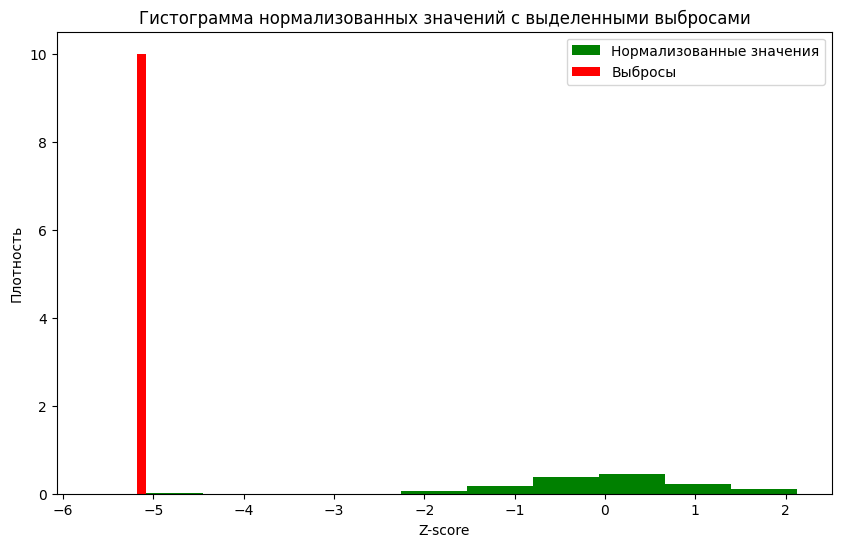

In [8]:
# постройте гистограмму нормализованных значений и выделите выбросы другим цветом
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(z_scores, color='green', label='Нормализованные значения', density=True)
plt.hist(z_scores[outliers_mask],color='red', label='Выбросы', density=True)
plt.xlabel('Z-score')
plt.ylabel('Плотность')
plt.title('Гистограмма нормализованных значений с выделенными выбросами')
plt.legend()
plt.show()

In [9]:
# отфильтруйте все элементы, находящиеся в пределах ±1σ, затем — в пределах ±1,5σ. Сравните количество таких элементов
within_1_sigma = np.abs(z_scores) <= 1
within_1_5_sigma = np.abs(z_scores) <= 1.5

count_1_sigma = np.sum(within_1_sigma)
count_1_5_sigma = np.sum(within_1_5_sigma)

print(f"Элементов в пределах ±1σ: {count_1_sigma}")
print(f"Элементов в пределах ±1.5σ: {count_1_5_sigma}")

Элементов в пределах ±1σ: 74
Элементов в пределах ±1.5σ: 90


In [10]:
# вычислите вручную ковариацию, дисперсию и корреляцию Пирсона между двумя массивами
# Используем array_uniform и array_normal для примера

# Дисперсия
var_uniform_manual = np.mean((array_uniform - np.mean(array_uniform))**2)
var_normal_manual = np.mean((array_normal - np.mean(array_normal))**2)

# Ковариация
cov_manual = np.mean((array_uniform - np.mean(array_uniform)) * (array_normal - np.mean(array_normal)))

# Корреляция Пирсона
corr_manual = cov_manual / (np.sqrt(var_uniform_manual) * np.sqrt(var_normal_manual))

print(f"Дисперсия array_uniform: {var_uniform_manual}")
print(f"Дисперсия array_normal: {var_normal_manual}")
print(f"Ковариация: {cov_manual}")
print(f"Корреляция Пирсона: {corr_manual}")

Дисперсия array_uniform: 1928.8403010062104
Дисперсия array_normal: 22.17742372457479
Ковариация: -4.54525199514007
Корреляция Пирсона: -0.021976285233107174


## 3. Срезы и условия

In [11]:
# выделите из равномерного массива все подпоследовательности длиной 3, в которых сумма > 30: через цикл for, numpy и сравните время выполнения
import time
from numpy.lib.stride_tricks import sliding_window_view
large_array = np.random.uniform(-100, 50, 10000000)

def find_subseq_loop(arr, threshold=30):
    result = []
    for i in range(len(arr) - 2):
        if sum(arr[i:i+3]) > threshold:
            result.append(arr[i:i+3])
    return result

def find_subseq_numpy(arr, threshold=30):
    windows = sliding_window_view(arr, window_shape=3)
    sums = np.sum(windows, axis=1)
    return windows[sums > threshold]

start = time.time()
loop_result = find_subseq_loop(large_array)
loop_time = time.time() - start

start = time.time()
numpy_result = find_subseq_numpy(large_array)
numpy_time = time.time() - start

print(f"Цикл: {len(loop_result)} последовательностей за {loop_time:.4f} сек")
print(f"NumPy: {len(numpy_result)} последовательностей за {numpy_time:.4f} сек")
print(f"Ускорение: {loop_time/numpy_time:.1f}x")

Цикл: 855581 последовательностей за 10.4559 сек
NumPy: 855581 последовательностей за 0.1668 сек
Ускорение: 62.7x


In [12]:
# реализуйте вручную алгоритм вычисления экспоненциального сглаживания (EMA) с фактором затухания 0.2 для массива с нормальным распределением
alpha = 0.2
ema_manual = np.zeros_like(array_normal)
ema_manual[0] = array_normal[0]

for i in range(1, len(array_normal)):
    ema_manual[i] = alpha * array_normal[i] + (1 - alpha) * ema_manual[i-1]

print(ema_manual)

[ 9.0508701  10.81238004 10.80667719  9.45196523  9.58963822  8.07335667
  7.74284332  6.95746951  7.76782613  9.47609353 10.67298791  9.95306025
  9.93109903  9.32363605  9.36511432  9.13981503  9.20154326  8.72666543
  6.13252544  7.26577455  9.22850865  8.75870556 10.11634861 10.01269943
 10.74457514 10.49222134 10.06928189 11.97575996 13.56843145 12.9835574
 11.43120721 11.64135659 10.33472318  9.35198846  9.24789156 11.32506844
  8.60152027  9.22056305  9.42764785  9.09052357  9.2651483  10.55711382
 10.77604002 10.22773346 10.52332334 11.09753208 10.71085578 11.75423458
 13.15412399 12.18445412  9.88083853  9.50601788  9.10696003  7.41140541
  8.67839842  8.94575654  9.39119481  9.51482018 10.63882264 10.90510716
 11.6688052  12.72674633 13.68285343 13.40563026 12.79926496 12.02292539
 11.11599979  9.94327485  9.69664393  7.74070451  8.32885126  8.57689273
  9.97668567  9.07209288  9.80818214  8.47629811  8.90572981  9.51737833
  8.59085961  9.33064222 10.01701482  8.82833388  9.

In [13]:
# реализуйте алгоритм вычисления экспоненциального сглаживания (EMA) с фактором затухания 0.2 через библиотеку Pandas
import pandas as pd

series = pd.Series(array_normal)
ema_pandas = series.ewm(alpha=0.2).mean().values

print(ema_pandas)

[ 9.0508701  13.94395326 12.64883546  9.73023178  9.85222677  7.72606766
  7.39573668  6.53545246  7.56892249  9.52724376 10.82542064 10.01963314
  9.98230522  9.3361843   9.37657401  9.14239112  9.20501427  8.72071794
  6.08985268  7.24495375  9.23016233  8.75653374 10.12267544 10.0172631
 10.75099805 10.49659076 10.07175023 11.98142848 13.57543287 12.98843187
 11.43356692 11.64341062 10.33553743  9.35214123  9.24797152 11.3258067
  8.60140358  9.2205983   9.42771046  9.09052884  9.26517109 10.55724197
 10.77615744 10.22779754 10.52338748 11.0976034  10.71090205 11.75429487
 13.15419719 12.18449884  9.88084801  9.50602203  9.10696044  7.41139583
  8.67839668  8.94575615  9.39119583  9.51482129 10.63882569 10.90511001
 11.66880841 12.72674993 13.68285707 13.405633   12.79926685 12.02292659
 11.11600045  9.94327508  9.69664406  7.74070429  8.32885117  8.57689268
  9.97668575  9.07209288  9.80818218  8.47629809  8.9057298   9.51737834
  8.5908596   9.33064222 10.01701484  8.82833388  9.6

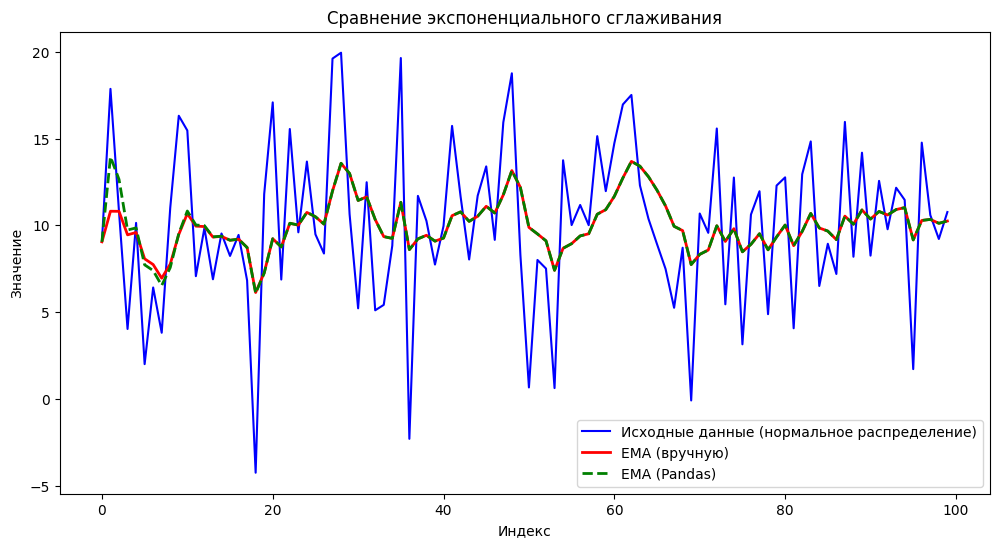

Разница между методами: 3.1315732282


In [14]:
# визуализируйте полученные EMA и сравните результаты
plt.figure(figsize=(12, 6))
plt.plot(array_normal,label='Исходные данные (нормальное распределение)', color='blue')
plt.plot(ema_manual, label='EMA (вручную)', linewidth=2, color='red')
plt.plot(ema_pandas, label='EMA (Pandas)', linewidth=2, linestyle='--', color='green')
plt.xlabel('Индекс')
plt.ylabel('Значение')
plt.title('Сравнение экспоненциального сглаживания')
plt.legend()
plt.show()

print(f"Разница между методами: {np.max(np.abs(ema_manual - ema_pandas)):.10f}")

## 4. Индексация и маски

In [15]:
# преобразуйте массив в матрицу 10×10 (reshape)
matrix_10x10 = array_normal.reshape(10, 10)
print(f"Форма матрицы: {matrix_10x10.shape}")
print(matrix_10x10)

Форма матрицы: (10, 10)
[[ 9.0508701  17.8584198  10.78386582  4.03311739 10.14033015  2.00823048
   6.4207899   3.81597428 11.00925262 16.30916311]
 [15.46056546  7.07334961  9.84325413  6.89378415  9.53102739  8.23861787
   9.44845616  6.82715414 -4.24403452 11.79877096]
 [17.07944509  6.87949318 15.54692084  9.59810271 13.67207799  9.48280612
   8.3775241  19.60167223 19.93911742 10.64406122]
 [ 5.22180645 12.48195411  5.1081895   5.42104962  8.83150395 19.63377597
  -2.29267242 11.69673416 10.25598706  7.74202644]
 [ 9.96364723 15.72497589 11.65174483  8.0345072  11.70568286 13.39436704
   9.16415058 15.9277498  18.75368159  8.30577464]
 [ 0.66637618  8.00673526  7.51072865  0.62918695 13.74637043 10.01518905
  11.17294787 10.00932167 15.13483249 11.97024525]
 [14.72359732 16.95851084 17.50728187 12.29673759 10.37380376  8.9175671
   7.48829737  5.25237511  8.71012025 -0.08305319]
 [10.68143828  9.56905863 15.57585743  5.45372172 12.75253919  3.148762
  10.62345658 11.96397242  4.8

In [16]:
# установите в NaN (np.nan) те элементы, которые являются локальными минимумами по строкам
matrix_with_nan = matrix_10x10.copy()

for i in range(matrix_with_nan.shape[0]):
    row = matrix_with_nan[i]
    for j in range(1, len(row)-1):
        if row[j] < row[j-1] and row[j] < row[j+1]:
            matrix_with_nan[i, j] = np.nan

print("Локальные минимумы по строкам заменены на NaN")
print("Матрица с NaN")
print(matrix_with_nan)

Локальные минимумы по строкам заменены на NaN
Матрица с NaN
[[ 9.0508701  17.8584198  10.78386582         nan 10.14033015         nan
   6.4207899          nan 11.00925262 16.30916311]
 [15.46056546         nan  9.84325413         nan  9.53102739         nan
   9.44845616  6.82715414         nan 11.79877096]
 [17.07944509         nan 15.54692084         nan 13.67207799  9.48280612
          nan 19.60167223 19.93911742 10.64406122]
 [ 5.22180645 12.48195411         nan  5.42104962  8.83150395 19.63377597
          nan 11.69673416 10.25598706  7.74202644]
 [ 9.96364723 15.72497589 11.65174483         nan 11.70568286 13.39436704
          nan 15.9277498  18.75368159  8.30577464]
 [ 0.66637618  8.00673526  7.51072865         nan 13.74637043         nan
  11.17294787         nan 15.13483249 11.97024525]
 [14.72359732 16.95851084 17.50728187 12.29673759 10.37380376  8.9175671
   7.48829737         nan  8.71012025 -0.08305319]
 [10.68143828         nan 15.57585743         nan 12.75253919     

# Задание 2. Работа с таблицами в Pandas

## 1. Создание DataFrame

In [17]:
# сгенерируйте таблицу на 500 строк с полями
np.random.seed(42)
n_rows = 500

# user_id (уникальные ID)
user_ids = np.arange(1, n_rows + 1)

# age (от 18 до 65)
ages = np.random.randint(18, 66, size=n_rows)

# income (зависит от возраста: например, income = age * random.normal(1.5, 0.2))
incomes = ages * np.random.normal(1.5, 0.2, size=n_rows)

# subscription_date (случайные даты за последние 2 года)
import pandas as pd
end_date = pd.Timestamp.now()
start_date = end_date - pd.DateOffset(years=2)
subscription_dates = pd.date_range(start_date, end_date, freq='D')
subscription_dates_sample = np.random.choice(subscription_dates, size=n_rows)

# region (случайно: «Север», «Юг», «Центр», «Восток», «Запад»)
regions = np.random.choice(['Север', 'Юг', 'Центр', 'Восток', 'Запад'], size=n_rows)

# is_active (булевый флаг активности пользователя)
is_active = np.random.choice([True, False], size=n_rows, p=[0.7, 0.3])

# Создаем DataFrame
df = pd.DataFrame({
    'user_id': user_ids,
    'age': ages,
    'income': incomes,
    'subscription_date': subscription_dates_sample,
    'region': regions,
    'is_active': is_active
})

df.head()

,user_id,age,income,subscription_date,region,is_active
0,1,56,81.732476,2025-01-10 21:36:20.384016,Запад,True
1,2,46,69.560249,2025-02-28 21:36:20.384016,Запад,True
2,3,32,52.141841,2023-10-26 21:36:20.384016,Запад,True
3,4,60,91.513138,2024-06-23 21:36:20.384016,Север,False
4,5,25,28.013115,2023-09-25 21:36:20.384016,Восток,True


## 2. Работа с признаками

In [42]:
# вычислите experience_months — количество месяцев с момента подписки
df['experience_months'] = ((pd.Timestamp.now() - df['subscription_date']).dt.days / 30).astype(int)
print(df['experience_months'])

0       8
1       6
2      22
3      14
4      23
       ..
495    14
496     6
497    13
498    24
499    11
Name: experience_months, Length: 500, dtype: int64


In [19]:
# создайте категориальный признак "income_group" по квантилям дохода
df['income_group'] = pd.qcut(df['income'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
print(df['income_group'])

0      Q4
1      Q3
2      Q2
3      Q4
4      Q1
       ..
495    Q2
496    Q3
497    Q1
498    Q1
499    Q4
Name: income_group, Length: 500, dtype: category
Categories (4, object): ['Q1' < 'Q2' < 'Q3' < 'Q4']


In [20]:
# постройте новую метрику — loyalty_score = income / (1 + experience_months)
df['loyalty_score'] = df['income'] / (1 + df['experience_months'])
print(df['loyalty_score'])

0      9.081386
1      9.937178
2      2.267037
3      6.100876
4      1.167213
         ...   
495    4.109861
496    9.864758
497    2.091328
498    1.051327
499    7.690165
Name: loyalty_score, Length: 500, dtype: float64


## 3. Фильтрация и агрегации

In [21]:
# найдите средний доход активных пользователей по регионам
avg_income_by_region = df[df['is_active'] == True].groupby('region')['income'].mean()
print("Средний доход активных пользователей по регионам:")
print(avg_income_by_region)

Средний доход активных пользователей по регионам:
region
Восток    69.917265
Запад     63.960071
Север     62.583037
Центр     61.680837
Юг        61.034761
Name: income, dtype: float64


In [22]:
# постройте сводную таблицу: средний loyalty_score по регионам и группам дохода
pivot_table = df.pivot_table(values='loyalty_score', index='region', columns='income_group', aggfunc='mean', observed=False)
print("Сводная таблица среднего loyalty_score по регионам и группам дохода:")
print(pivot_table)

Сводная таблица среднего loyalty_score по регионам и группам дохода:
income_group        Q1         Q2         Q3         Q4
region                                                 
Восток        4.085425   9.603175  24.978809   7.405031
Запад         5.927313   7.515662  16.591228  11.478510
Север         5.474256  10.140783   7.286187  19.067026
Центр         3.592925   7.595971  11.928946   8.915772
Юг            6.094829  10.479838   9.791537  11.856264


In [23]:
# найдите 5% пользователей с наибольшим loyalty_score
top_5_percent = df.nlargest(int(len(df) * 0.05), 'loyalty_score')
print(f"Найдено {len(top_5_percent)} пользователей (5% от {len(df)}) с наибольшим loyalty_score")
print(top_5_percent[['user_id', 'loyalty_score', 'income', 'region']].head(int(len(df) * 0.05)))

Найдено 25 пользователей (5% от 500) с наибольшим loyalty_score
     user_id  loyalty_score      income  region
120      121     117.211033  117.211033   Север
381      382      87.267418   87.267418      Юг
349      350      83.449108   83.449108   Север
350      351      80.178193   80.178193   Запад
452      453      77.259417   77.259417  Восток
249      250      75.376258   75.376258  Восток
459      460      75.057483   75.057483  Восток
84        85      68.430329   68.430329  Восток
254      255      68.123088   68.123088  Восток
5          6      66.732110   66.732110   Запад
261      262      66.669875   66.669875  Восток
341      342      66.146554   66.146554   Запад
42        43      65.886223   65.886223   Запад
407      408      65.756761   65.756761  Восток
445      446      64.215499   64.215499   Центр
215      216      61.304635   61.304635  Восток
294      295      60.990899   60.990899   Север
464      465      55.571625   55.571625      Юг
16        17      53.646

## 4. Обработка пропусков и ошибок

In [24]:
# случайно удалите 5% значений из income, замените их средним значением по региону
df_with_missing = df.copy()

# Определяем индексы для удаления (5% от данных)
n_missing = int(len(df_with_missing) * 0.05)
missing_indices = np.random.choice(df_with_missing.index, size=n_missing, replace=False)

# Устанавливаем NaN
df_with_missing.loc[missing_indices, 'income'] = np.nan

# Заменяем пропущенные значения средним по региону
df_with_missing['income'] = df_with_missing.groupby('region')['income'].transform(
    lambda x: x.fillna(x.mean())
)

print(f"Удалено {n_missing} значений income и заменено средним по региону")

Удалено 25 значений income и заменено средним по региону


In [25]:
# проведите интерполяцию по времени подписки (если есть пропуски)

df_sorted = df_with_missing.sort_values('subscription_date').copy()
df_for_interpolation = df_sorted.copy()
interpolation_indices = np.random.choice(df_for_interpolation.index[:100], size=5, replace=False)
df_for_interpolation.loc[interpolation_indices, 'income'] = np.nan
df_for_interpolation = df_for_interpolation.set_index('subscription_date').sort_index()
df_for_interpolation['income_interpolated'] = df_for_interpolation['income'].interpolate(method='time')
df_for_interpolation.head()

,user_id,age,income,region,is_active,experience_months,income_group,loyalty_score,income_interpolated
subscription_date,,,,,,,,,
2023-09-11 21:36:20.384016,499,22,26.283172,Запад,True,24,Q1,1.051327,26.283172
2023-09-11 21:36:20.384016,384,26,33.243057,Запад,False,24,Q1,1.329722,33.243057
2023-09-12 21:36:20.384016,133,54,67.359715,Восток,True,24,Q4,3.289620,67.359715
2023-09-12 21:36:20.384016,75,48,76.729790,Центр,True,24,Q3,3.069192,76.729790
2023-09-16 21:36:20.384016,201,58,77.598132,Восток,False,24,Q3,3.103925,77.598132


## 5. Контроль значений

In [26]:
# реализуйте функцию контроля значений: выбрасывайте строки, где income или age стали некорректными (например, отрицательными)
def validate_data(dataframe):
    initial_count = len(dataframe)
    
    # Удаляем строки с отрицательным income или age
    valid_df = dataframe[(dataframe['income'] >= 0) & (dataframe['age'] >= 0)]
    
    final_count = len(valid_df)
    removed_count = initial_count - final_count
    
    print(f"Изначально строк: {initial_count}")
    print(f"Удалено некорректных строк: {removed_count}")
    print(f"Осталось строк: {final_count}")
    
    return valid_df

# Применяем функцию к датафрейму
df_cleaned = validate_data(df_with_missing)

Изначально строк: 500
Удалено некорректных строк: 0
Осталось строк: 500


# Задание 3. Визуализация многомерных и категориальных данных
## 1. Обзор данных

In [27]:
# ознакомьтесь с описанием признаков
import seaborn as sns
diamonds = sns.load_dataset("diamonds")
print(diamonds.info())
diamonds.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [28]:
# проверьте данные на наличие дубликатов и пропусков, устраните их при наличии
print(f"Количество дубликатов: {diamonds.duplicated().sum()}")
print(f"Количество пропусков по столбцам:")
print(diamonds.isnull().sum())

# Удаляем дубликаты, если есть
diamonds_clean = diamonds.drop_duplicates()
print(f"Дубликаты удалены. Новый размер: {diamonds_clean.shape}")

Количество дубликатов: 146
Количество пропусков по столбцам:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
Дубликаты удалены. Новый размер: (53794, 10)


In [29]:
# преобразуйте признаки cut, color, clarity в упорядоченные категории согласно логике качества
diamonds['cut'] = pd.Categorical(diamonds['cut'], 
                                categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], 
                                ordered=True)
diamonds['color'] = pd.Categorical(diamonds['color'], 
                                  categories=['J', 'I', 'H', 'G', 'F', 'E', 'D'], 
                                  ordered=True)
diamonds['clarity'] = pd.Categorical(diamonds['clarity'], 
                                    categories=['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'], 
                                    ordered=True)


## 2. Визуализация одномерных распределений

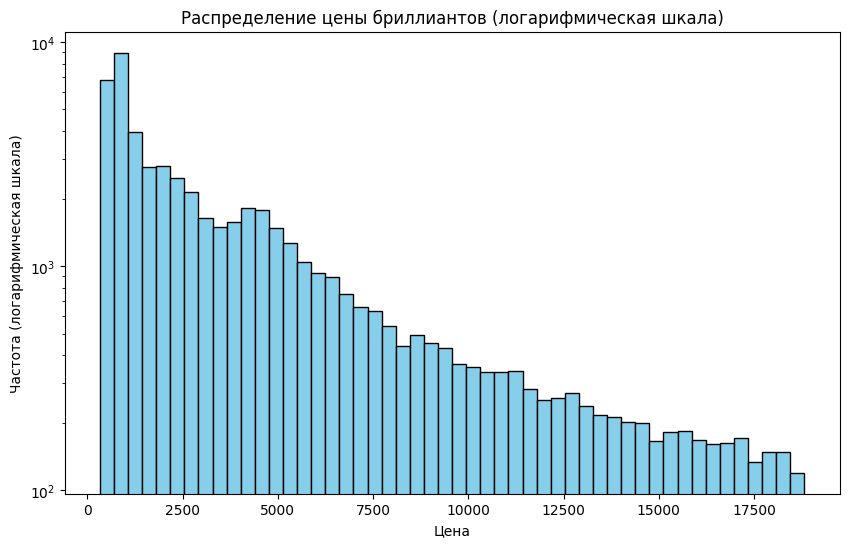

In [30]:
# постройте гистограмму распределения переменной price с логарифмическим масштабом
plt.figure(figsize=(10, 6))
plt.hist(diamonds_clean['price'], bins=50, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.xlabel('Цена')
plt.ylabel('Частота (логарифмическая шкала)')
plt.title('Распределение цены бриллиантов (логарифмическая шкала)')
plt.show()

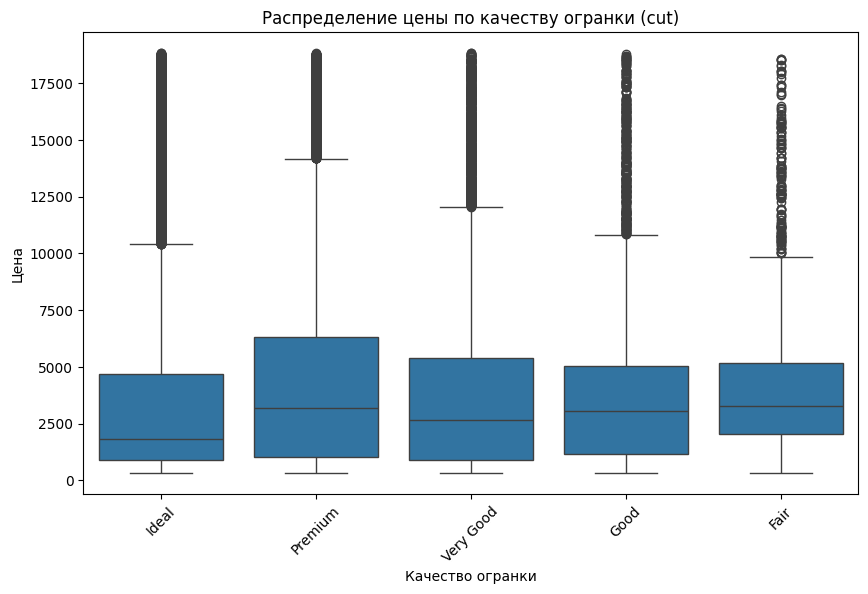

In [31]:
# постройте boxplot для распределения price в зависимости от cut
plt.figure(figsize=(10, 6))
sns.boxplot(data=diamonds_clean, x='cut', y='price')
plt.title('Распределение цены по качеству огранки (cut)')
plt.xlabel('Качество огранки')
plt.ylabel('Цена')
plt.xticks(rotation=45)
plt.show()

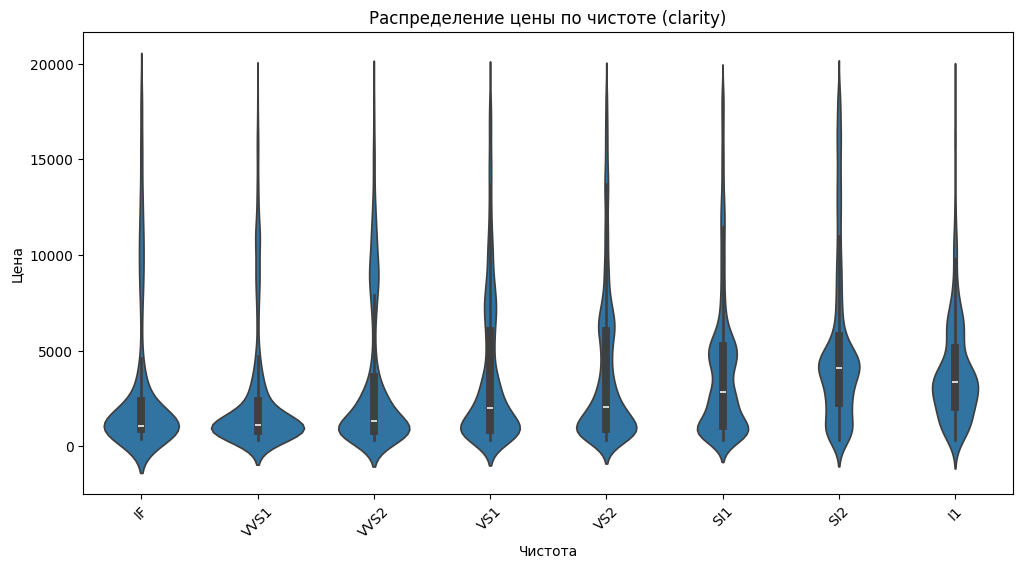

In [32]:
# постройте violinplot для price в зависимости от clarity и проанализируйте, где наблюдаются выбросы
plt.figure(figsize=(12, 6))
sns.violinplot(data=diamonds_clean, x='clarity', y='price')
plt.title('Распределение цены по чистоте (clarity)')
plt.xlabel('Чистота')
plt.ylabel('Цена')
plt.xticks(rotation=45)
plt.show()

# Анализ выбросов: выбросы наблюдаются в категориях с высокой ценой и малым количеством данных

## 3. Анализ многомерных зависимостей

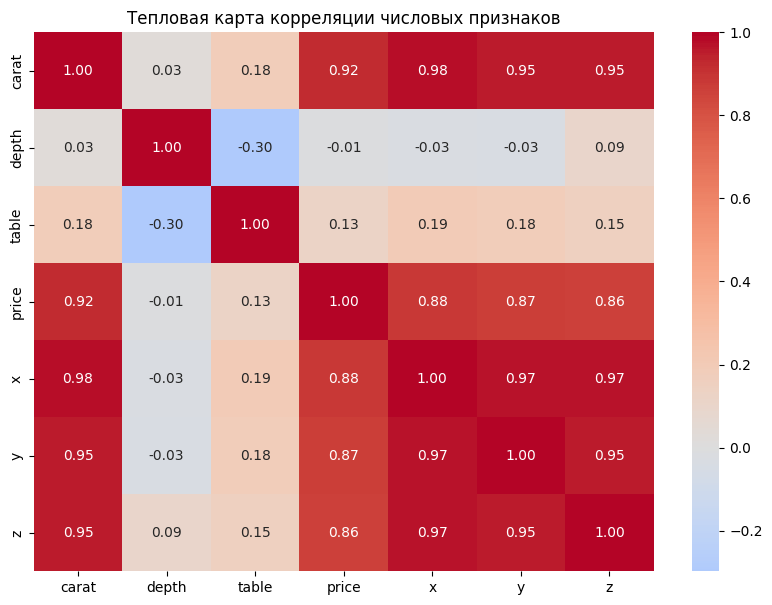

In [44]:
# постройте тепловую карту корреляции между числовыми признаками
numeric_columns = diamonds_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = diamonds_clean[numeric_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Тепловая карта корреляции числовых признаков')
plt.show()

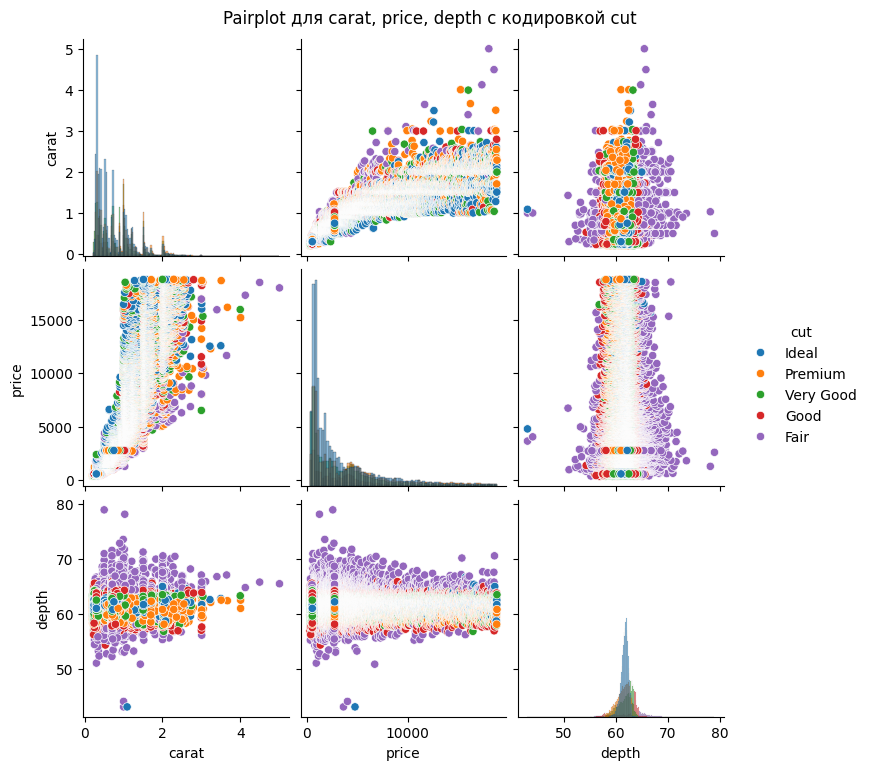

In [34]:
# постройте pairplot для признаков carat, price, depth, закодировав cut как цвет (hue)
sns.pairplot(diamonds_clean[['carat', 'price', 'depth', 'cut']], hue='cut', diag_kind='hist')
plt.suptitle('Pairplot для carat, price, depth с кодировкой cut', y=1.02)
plt.show()

In [35]:
# проанализируйте, какая комбинация признаков наиболее визуально предсказывает цену (price)
# Наиболее сильная корреляция наблюдается между carat и price
# Это видно как на тепловой карте корреляций, так и на pairplot
print("Наиболее визуально предсказывающая цена комбинация признаков: carat")
print("Наблюдается сильная положительная зависимость между весом бриллианта (carat) и его ценой (price)")

Наиболее визуально предсказывающая цена комбинация признаков: carat
Наблюдается сильная положительная зависимость между весом бриллианта (carat) и его ценой (price)


## 4. Визуализация категориальных признаков

In [45]:
# постройте сводную таблицу, показывающую среднюю цену в зависимости от cut и color
pivot_price = diamonds_clean.pivot_table(values='price', index='cut', columns='color', aggfunc='mean', observed=False)
print("Сводная таблица средней цены по cut и color:")
print(pivot_price)

Сводная таблица средней цены по cut и color:
color                D            E            F            G            H  \
cut                                                                          
Ideal      2635.239107  2601.217056  3378.721131  3728.445838  3896.114369   
Premium    3634.493433  3542.385242  4327.297286  4498.782728  5217.907274   
Very Good  3472.662252  3215.471030  3777.724457  3874.210183  4524.835074   
Good       3408.107576  3425.748657  3497.254405  4114.074799  4246.585122   
Fair       4291.061350  3689.743243  3834.750809  4227.000000  5091.307692   

color                I            J  
cut                                  
Ideal      4452.125359  4922.871365  
Premium    5934.466245  6287.733251  
Very Good  5257.477140  5110.304284  
Good       5032.471042  4587.833333  
Fair       4607.534483  4975.655462  


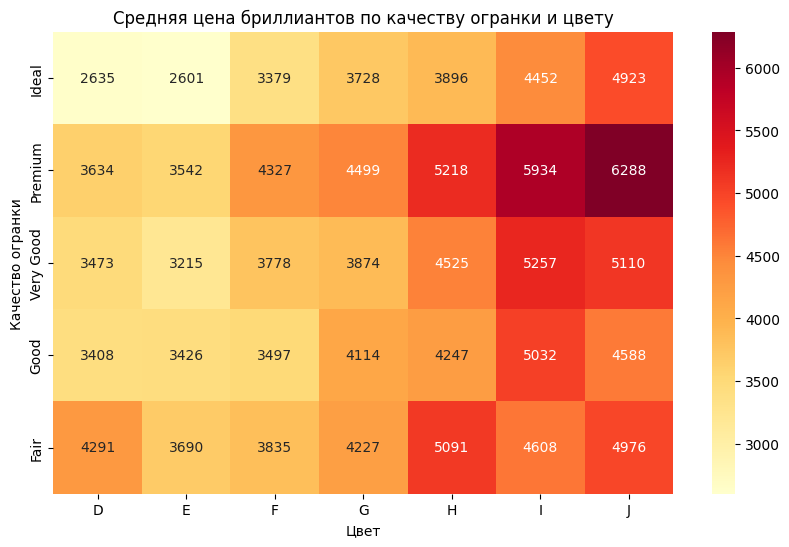

In [37]:
# На ее основе постройте тепловую карту
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_price, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Средняя цена бриллиантов по качеству огранки и цвету')
plt.xlabel('Цвет')
plt.ylabel('Качество огранки')
plt.show()

In [38]:
# Какой цвет и огранка в среднем наиболее дорогие?
# Находим максимальное значение в сводной таблице
max_price = pivot_price.max().max()
max_position = pivot_price.stack().idxmax()

print(f"Наиболее дорогие бриллианты:")
print(f"Качество огранки: {max_position[0]}")
print(f"Цвет: {max_position[1]}")
print(f"Средняя цена: {max_price:.0f}")

# Есть ли закономерности?
print("\nЗакономерности:")
print("1. Более высокое качество огранки (Ideal) обычно соответствует более высокой цене")
print("2. Цвета (J, I, H) обычно дороже")

Наиболее дорогие бриллианты:
Качество огранки: Premium
Цвет: J
Средняя цена: 6288

Закономерности:
1. Более высокое качество огранки (Ideal) обычно соответствует более высокой цене
2. Цвета (J, I, H) обычно дороже


# Задание 4. Визуализация категориальных признаков

In [39]:
# Необходимо реализовать функцию скользящего окна для заданного одномерного ряда данных
def sliding_window(x, w, step=1):
    if len(x) < w:
        return np.array([]).reshape(0, w)
    n_windows = (len(x) - w) // step + 1
    result = np.zeros((n_windows, w))
    for i in range(n_windows):
        start_idx = i * step
        end_idx = start_idx + w
        if end_idx <= len(x):
            result[i] = x[start_idx:end_idx]
        else: break
    return result
# Проверить корректность работы программы с помощью следующего кода
window, step_s = 3, 1
x1 = np.array([8, 1, 4, 5, -2, 5, 9, 0])
A1 = np.array([[8, 1, 4],
               [1, 4, 5],
               [4, 5, -2],
               [5, -2, 5],
               [-2, 5, 9],
               [5, 9, 0]])
result1 = sliding_window(x1, w=window, step=step_s)
print(np.array_equal(result1, A1))
window, step_s = 2, 4
x2 = np.array([8, 3, 4, 1, -6, 5, 9, 2, 10, 11, -14, 0])
A2 = np.array([[8, 3],
               [-6, 5],
               [10, 11]])
result2 = sliding_window(x2, w=window, step=step_s)
print(np.array_equal(result2, A2))

True
True
